In [28]:
!pip install ultralytics

import os
import numpy as np
import tensorflow as tf
from PIL import Image, ImageFile
from ultralytics import YOLO
from google.colab import drive

# Mount Drive to access saved models
drive.mount('/content/drive')

# Fix for potential image loading issues mentioned in your preprocessing
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ==========================================
# 1. CONFIGURATION & MODEL LOADING
# ==========================================
# Paths based on your Results directories
YOLO_MODEL_PATH = '/content/drive/MyDrive/Research/Results_YOLO/yolo_leukemia_cls_final.pt'
CNN_MODEL_PATH = '/content/drive/MyDrive/Research/Results_cnn/best_leukemia_model.keras'

print("Loading Models...")
yolo_model = YOLO(YOLO_MODEL_PATH)
cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)
print("✅ Models loaded successfully.")

# ==========================================
# 2. HYBRID PREDICTION ENGINE
# ==========================================
def hybrid_predict(image_path, yolo_weight=0.5, cnn_weight=0.5):
    """
    Combines YOLO and CNN outputs using weighted averaging.
    Weights can be adjusted based on which model performed better in logs.
    """

    # --- YOLO Prediction ---
    # YOLOv8-cls returns class probabilities
    yolo_results = yolo_model(image_path, verbose=False)[0]
    # Class 0: ALLNeg, Class 1: ALLPos
    yolo_prob = yolo_results.probs.data[1].item()

    # --- CNN Prediction ---
    # CNN requires 128x128 input as per your development file
    img = Image.open(image_path).convert('RGB').resize((128, 128))
    img_array = np.array(img) / 255.0  # Rescale matching your ImageDataGenerator
    img_array = np.expand_dims(img_array, axis=0)

    # CNN output is a sigmoid probability for ALLPos
    cnn_prob = cnn_model.predict(img_array, verbose=0)[0][0]

    # --- Hybrid Logic ---
    # Weighted ensemble calculation
    combined_score = (yolo_prob * yolo_weight) + (cnn_prob * cnn_weight)

    final_class = "ALLPos" if combined_score >= 0.5 else "ALLNeg"
    confidence = combined_score if combined_score >= 0.5 else (1 - combined_score)

    return {
        "final_prediction": final_class,
        "confidence": confidence,
        "yolo_score": yolo_prob,
        "cnn_score": cnn_prob
    }


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Models...
✅ Models loaded successfully.


Saving WBC-Benign-061.jpg to WBC-Benign-061.jpg
Uploaded file: WBC-Benign-061.jpg

Displaying: WBC-Benign-061.jpg


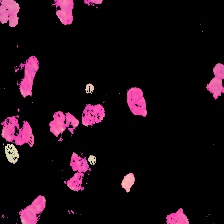


Running hybrid prediction...
Result: ALLNeg (Confidence: 99.82%)
  YOLO Score: 0.03%
  CNN Score: 0.40%


In [29]:
from google.colab import files
from IPython.display import Image as DisplayImage, display

uploaded = files.upload()

# Assuming only one file is uploaded, get its name
for filename in uploaded.keys():
    uploaded_image_path = filename
    print(f"Uploaded file: {uploaded_image_path}")

if 'uploaded_image_path' in locals():
    # Display the uploaded image
    print(f"\nDisplaying: {uploaded_image_path}")
    display(DisplayImage(filename=uploaded_image_path))

    print("\nRunning hybrid prediction...")
    result = hybrid_predict(uploaded_image_path, yolo_weight=0.6, cnn_weight=0.4)
    print(f"Result: {result['final_prediction']} (Confidence: {result['confidence']:.2%})")
    print(f"  YOLO Score: {result['yolo_score']:.2%}")
    print(f"  CNN Score: {result['cnn_score']:.2%}")
else:
    print("No image was uploaded.")